# Laboratorio 4 – Aprendizaje de máquina  
## Agrupación de pasajeros para la identificación de patrones de comportamiento en VuelaAlpes

### Integrantes:

1. Juan Sebastian Rodriguez Torres - 202214617 - js.rodriguezt1@uniandes.edu.co  
2. Luis Felipe Sales Galviz - 202211531 - l.sales@uniandes.edu.co 

---

### 1. Problema:

Aqui buscamos identificar grupos de pasajeros con características y comportamientos similares dentro de la aerolínea VuelaAlpes.
Buscamos descubrir patrones relevantes en los datos históricos de los pasajeros mediante técnicas de clustering, para dividir a usuarios según aspectos como características del vuelo, percepción de calidad del servicio. Como aqui no existe una variable objetivo conocida buscamos encontrar estructuras dentro de los datos utilizando algoritmos de agrupación.

### 2. Carga de datos y librerías

En esta sección se importarán las librerías necesarias para el desarrollo del laboratorio y se cargará el conjunto de datos dado por VuelaAlpes.
Creamos también una copia del dataset original para mantener los datos sin modificar durante el proceso de análisis y preparación.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

df_real = pd.read_csv(
    "./data/Datos_VuelaAlpes.csv",
    encoding="latin1"
)

df = df_real.copy()

print("Dimensiones del dataset:")
print(df.shape)

display(df.head(8))

Dimensiones del dataset:
(10000, 23)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,119496,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,...,4,4,4,2,5,4,4,4,9,6.0
1,60419,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,...,4,4,4,4,4,4,4,4,26,9.0
2,9671,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,...,4,4,4,4,4,3,4,4,68,42.0
3,59115,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,...,1,4,4,2,5,4,5,4,7,39.0
4,75857,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,...,3,3,5,5,4,5,4,3,0,0.0
5,73556,Male,Loyal Customer,45,Business travel,Business,1684,0,5,0,...,5,5,5,5,5,4,5,5,0,8.0
6,48923,Female,Loyal Customer,33,Business travel,Eco,153,5,5,5,...,5,5,2,2,4,5,5,5,3,0.0
7,152,Female,Loyal Customer,51,Business travel,Business,3424,3,4,4,...,3,3,3,3,3,4,3,4,44,42.0


### 3. Exploración y análisis de los datos

En esta sección se realizará una exploración detallada del conjunto de datos con el objetivo de comprender sus características principales e identificar posibles problemas que deban ser corregidos en los datos antes de ser procesados por los modelos.

Queremos identificar:
- Número de datos
- Tipos de variables presentes
- Distribución de los datos
- Valores faltantes
- Registros duplicados
- Distribución de variables
- Presencia de valores atípicos
- Posibles correlaciones entre clases
- Relaciones entre atributos de pasajeros y características de los vuelos
- Variables redundantes
- Posibles agrupamientos naturales visibles en los datos

In [4]:
print("Información general:")
display(df.info())

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 10000 non-null  int64  
 1   Gender                             10000 non-null  object 
 2   Customer Type                      10000 non-null  object 
 3   Age                                10000 non-null  int64  
 4   Type of Travel                     10000 non-null  object 
 5   Class                              10000 non-null  object 
 6   Flight Distance                    10000 non-null  int64  
 7   Inflight wifi service              10000 non-null  int64  
 8   Departure/Arrival time convenient  10000 non-null  int64  
 9   Ease of Online booking             10000 non-null  int64  
 10  Gate location                      10000 non-null  int64  
 11  Food and drink                    

None

In [7]:
print("\nCantidad de variables por tipo:")
display(df.dtypes.value_counts())


Cantidad de variables por tipo:


int64      18
object      4
float64     1
Name: count, dtype: int64

In [8]:
print("Variables numéricas:")
display(df.describe())

print("Variables categóricas:")
display(df.describe(include="object"))

Variables numéricas:


,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,9975.000000
mean,64983.058500,39.404300,1196.044800,2.734700,3.074000,2.762600,3.002800,3.215200,3.234500,3.431300,3.361900,3.391000,3.34440,3.635800,3.291700,3.643700,3.281200,14.86020,15.215439
std,37610.205164,15.072364,1000.590808,1.328718,1.520511,1.394287,1.283182,1.324486,1.350293,1.314935,1.329099,1.287123,1.31809,1.184271,1.263951,1.183085,1.311068,36.78467,37.370561
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,0.00000,0.000000
25%,32452.000000,27.000000,416.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,3.000000,2.000000,3.000000,2.000000,0.00000,0.000000
50%,64815.500000,40.000000,846.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.00000,4.000000,3.000000,4.000000,3.000000,0.00000,0.000000
75%,97470.000000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,5.000000,4.000000,5.000000,4.000000,13.00000,13.000000
max,129879.000000,80.000000,4963.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,930.00000,952.000000


Variables categóricas:


,Gender,Customer Type,Type of Travel,Class
count,10000,10000,10000,10000
unique,2,2,2,3
top,Female,Loyal Customer,Business travel,Business
freq,5140,8155,6934,4856


In [12]:
duplicados = df.duplicated().sum()

print(f"Cantidad de registros duplicados: {duplicados}")

Cantidad de registros duplicados: 0


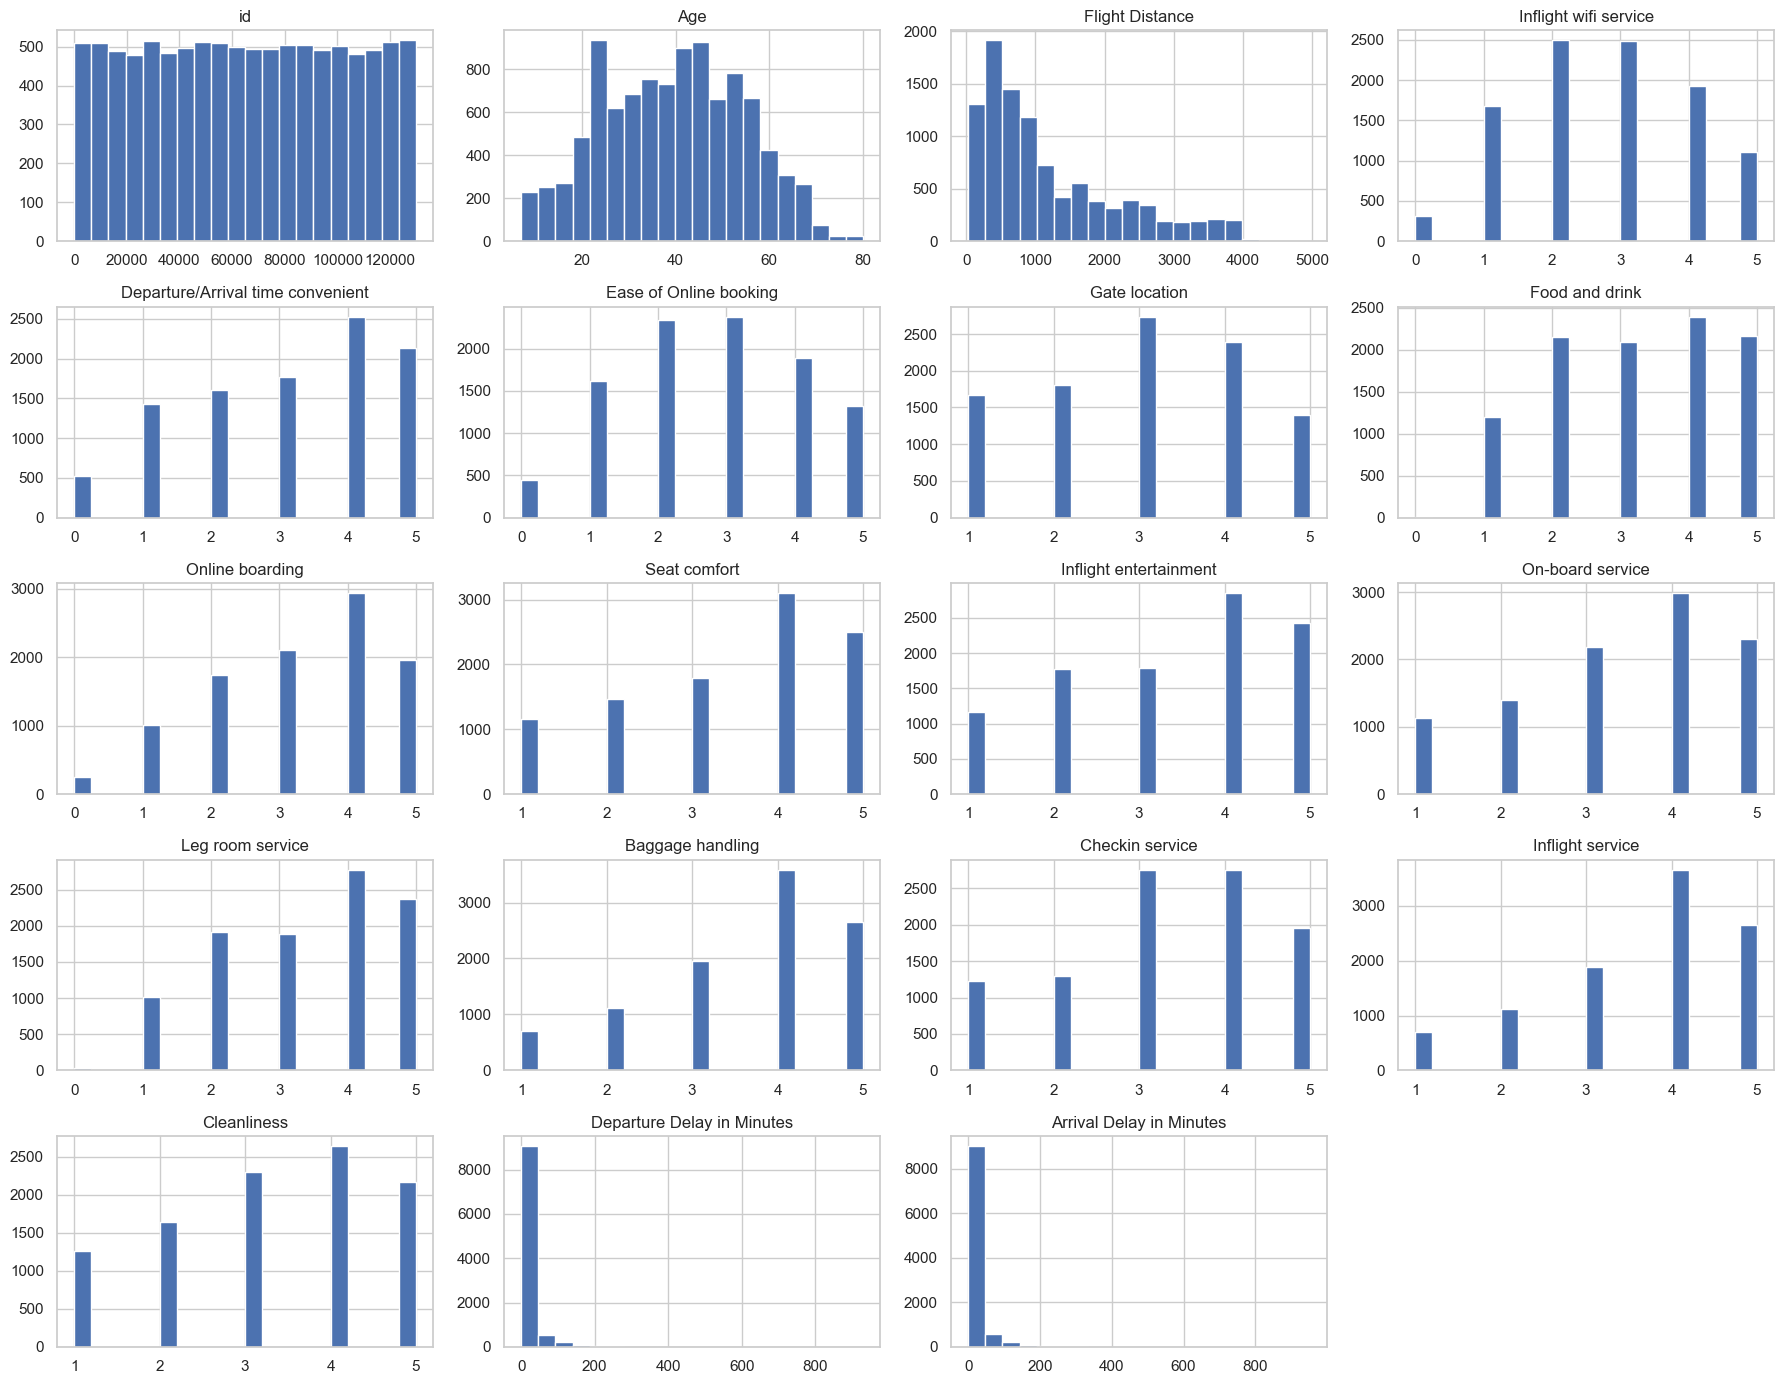

In [13]:
variables_numericas = df.select_dtypes(include=np.number).columns

df[variables_numericas].hist(
    figsize=(18,14),
    bins=20
)

plt.tight_layout()
plt.show()

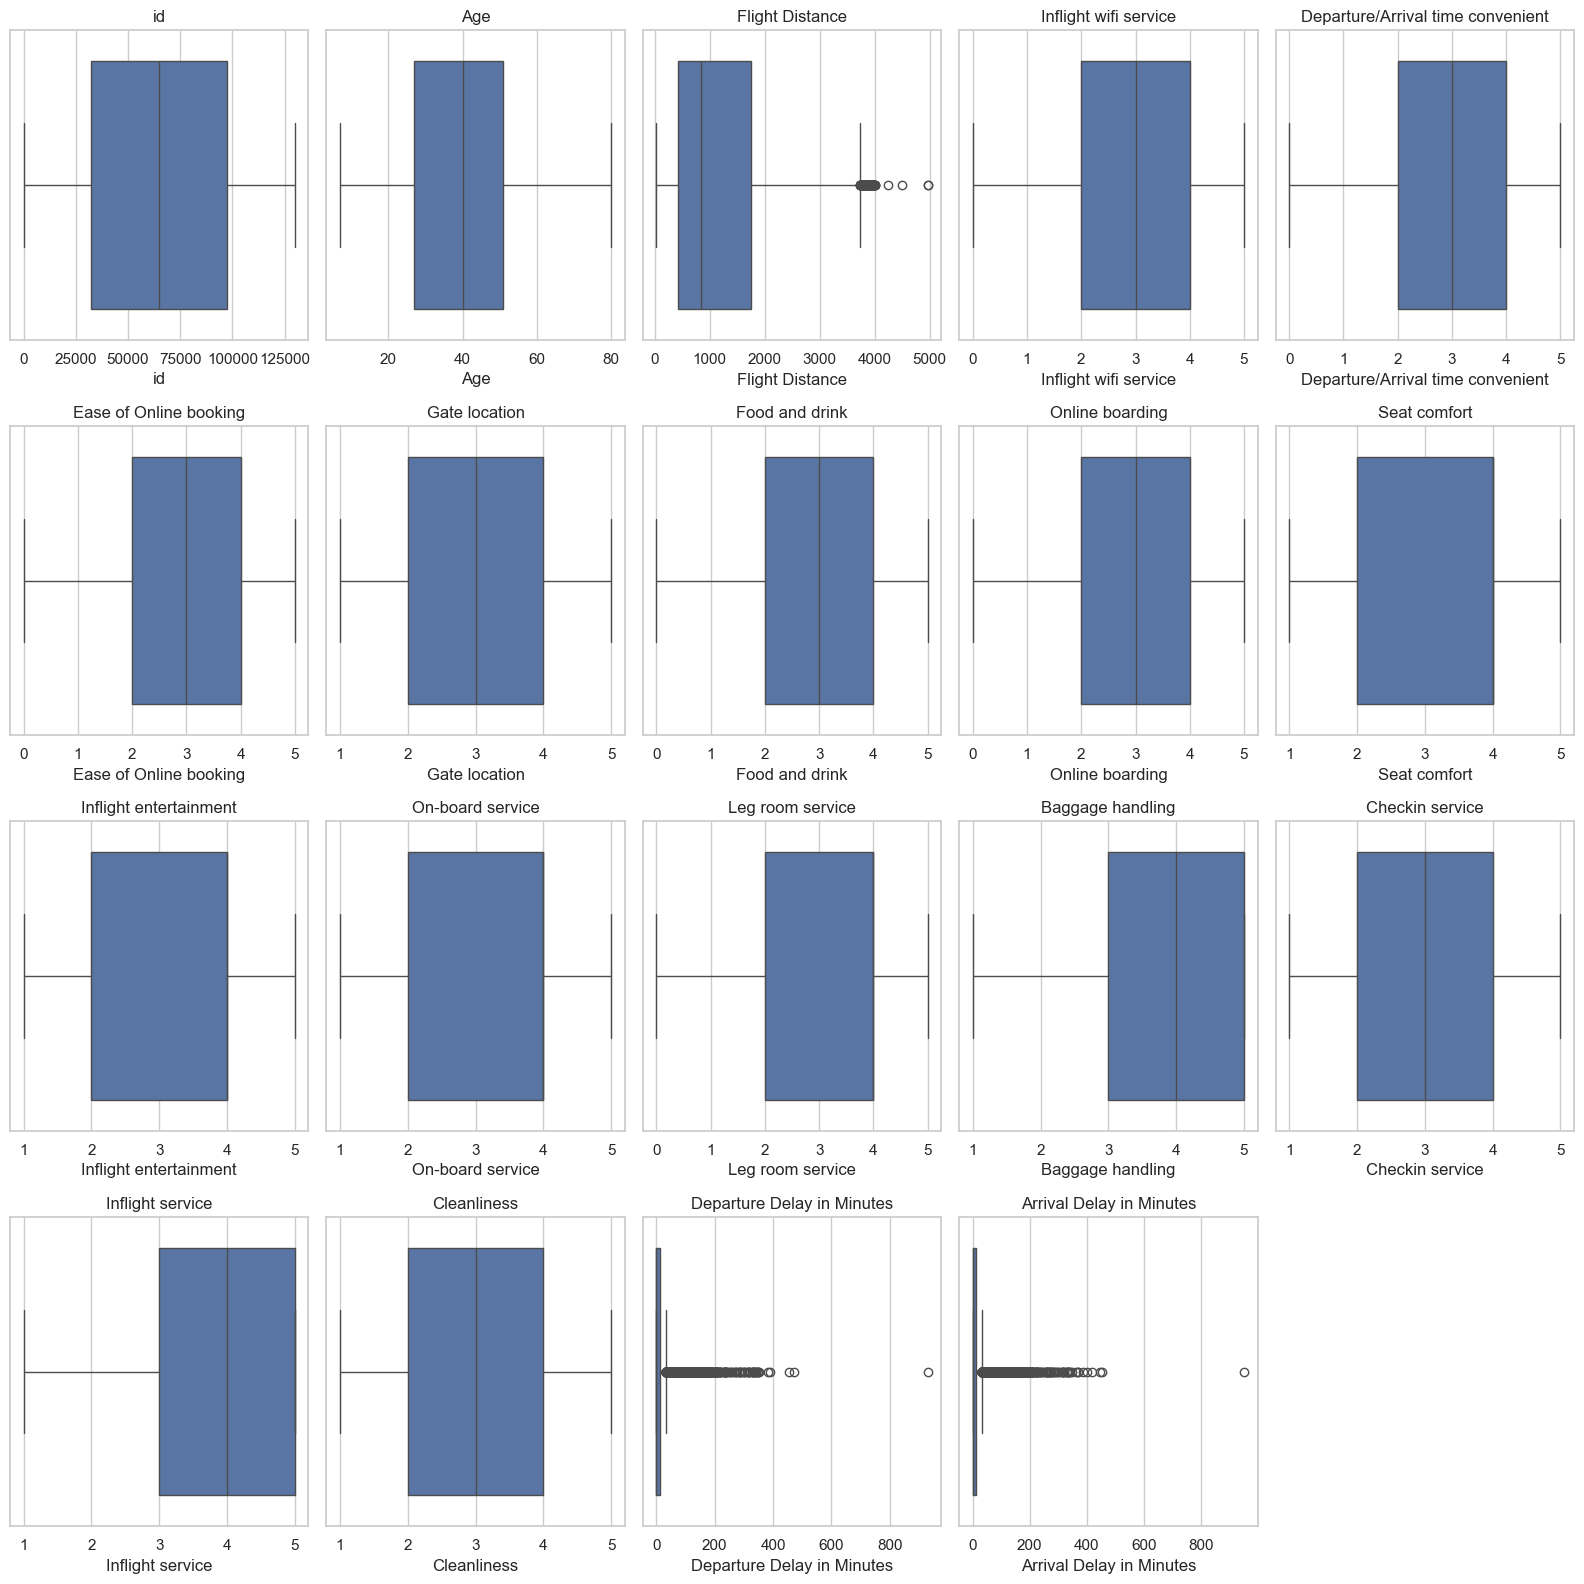

In [22]:
col = 5
fil = int(np.ceil(len(variables_numericas) / col))

fig, axes = plt.subplots(fil, col, figsize=(16, 4 * fil))

axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

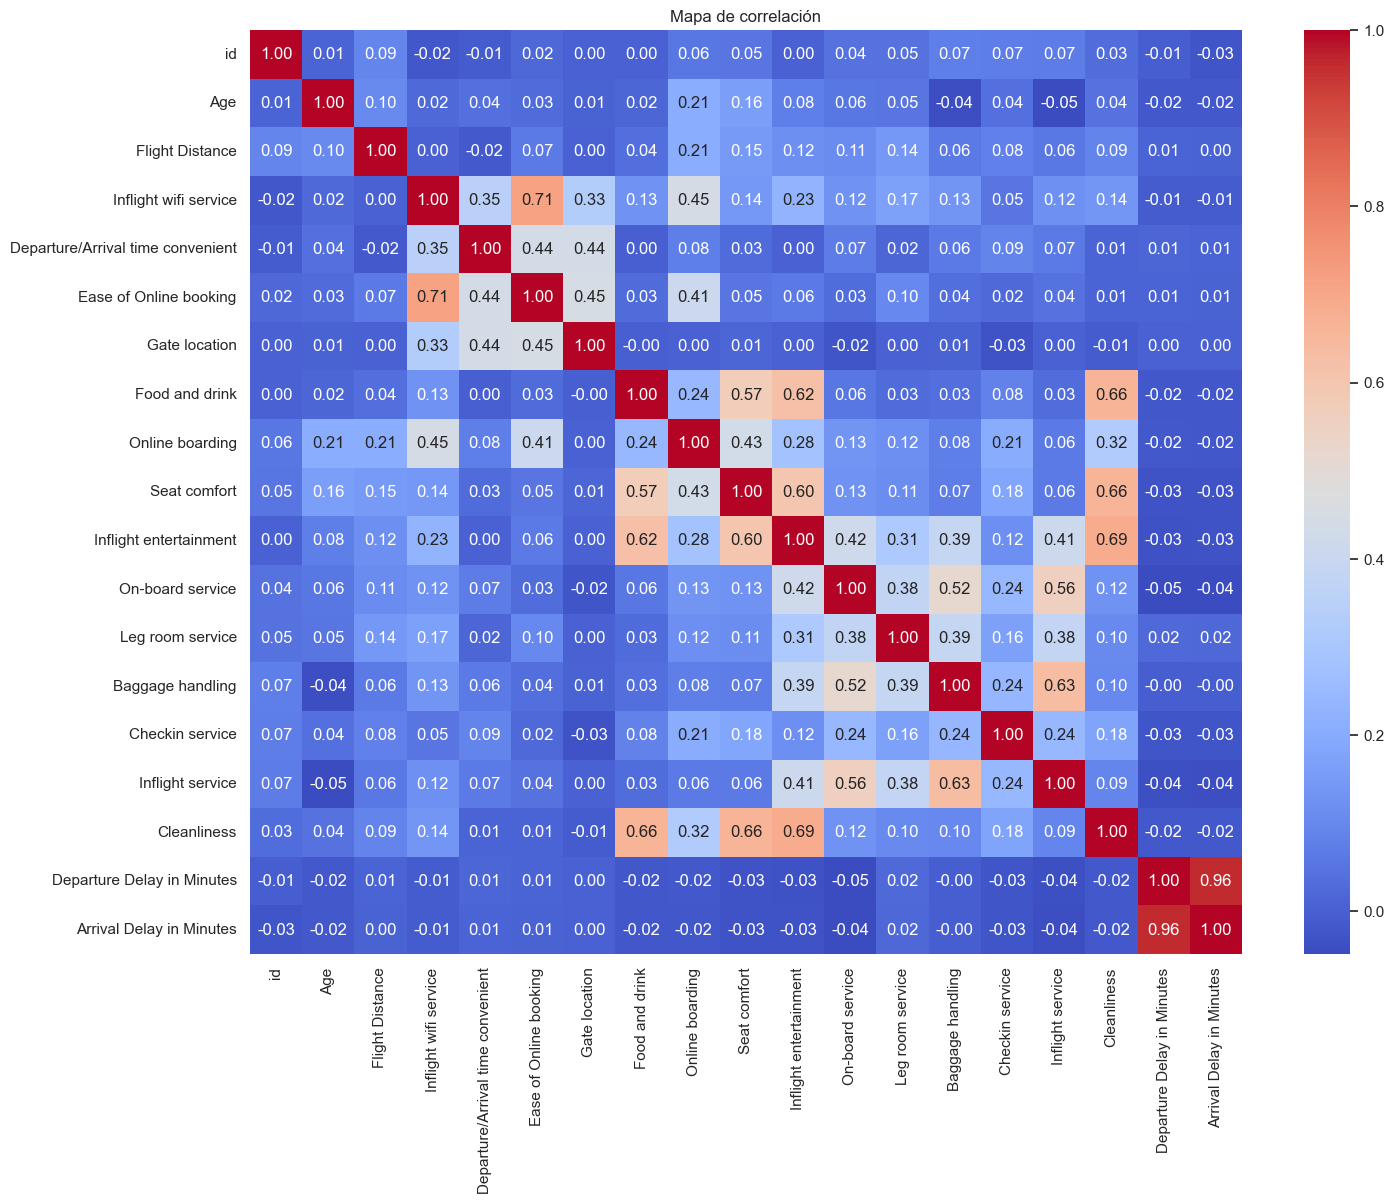

In [23]:
correlacion = df[variables_numericas].corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mapa de correlación")
plt.show()

### 4. Limpieza y preparación de datos

Con base en los hallazgos obtenidos durante la exploración se realizará el proceso de limpieza y preparación de los datos.

Identificamos que la variable Arrival Delay in Minutes presenta valores faltantes en 25 registros. También se observó que las variables Departure Delay in Minutes y Arrival Delay in Minutes presentan una alta correlacion, ambas representan prácticamente la misma información relacionada con retrasos en el vuelo. Por esta razón, se decidió eliminar la variable Arrival Delay in Minutes para no eliminar los registros con datos faltantes ya que no son necesarios al tener, conservando únicamente Departure Delay in Minutes, lo que permite reducir redundancia en los datos sin perder información relevante

Respecto a la detección de valores atípicos, aunque algunas variables contienen valores altos o poco frecuentes, estos representan situaciones posibles dentro del contexto real de los vuelos y no evidencian inconsistencias graves, por lo que no se eliminaran

Finalmente, debido a que los algoritmos de agrupación dependen directamente de las distancias entre observaciones, vamos a  transformar adecuadamente las variables categóricas y escalar las variables numéricas para que todas las características contribuyan de manera equilibrada al proceso de agrupamiento y evitará que variables con escalas mayores dominen el cálculo de distancias.

In [30]:
df = df.drop(columns=[
    "Arrival Delay in Minutes",
    "id"
])

print(df.shape)
display(df.head())

(10000, 21)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes
0,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,3,...,4,4,4,4,2,5,4,4,4,9
1,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,4,...,4,4,4,4,4,4,4,4,4,26
2,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,5,...,4,4,4,4,4,4,3,4,4,68
3,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,1,...,3,1,4,4,2,5,4,5,4,7
4,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,2,...,3,3,3,5,5,4,5,4,3,0


### 5. Construcción del pipeline de preprocesamiento

En esta sección se construirá un pipeline de preprocesamiento que permitirá integrar de manera organizada todas las transformaciones necesarias antes del entrenamiento de los modelos de agrupación esto lo hacemos para mantener la consistencia y asegurar que todos los algoritmos sean evaluados utilizando exactamente el mismo proceso de preparación de datos.

Vamos a:
- Separar variables numéricas y categóricas
- Escalar las variables numéricas mediante estandarización
- Codificar variables categóricas utilizando One-Hot Encoding
- Integrar todas las transformaciones en un único pipeline para reusarlo despues

In [ ]:
numericas = df.select_dtypes(include=np.number).columns

categoricas = df.select_dtypes(include="object").columns

print("Variables numéricas:")
print(numericas)

print("\nVariables categóricas:")
print(categoricas)

### 6. Modelo de agrupación basado en Gaussian Mixture Models GMM

### 7. Modelo de agrupación basado en DBSCAN

### 8. Modelo de agrupación basado en K-Means

### 9. Evaluación cuantitativa y comparación de modelos

En esta sección se comparará el desempeño de los distintos algoritmos de agrupación implementados, se realizará utilizando métricas de clustering, las cuales permiten evaluar la calidad de los grupos sin necesidad de contar con etiquetas reales.

### 10. Evaluación cualitativa e interpretación de grupos

En esta sección se analizarán e interpretarán los grupos generados por el mejor modelo de los que hicimos anteriormente para comprender las características principales de cada cluster y relacionarlas con posibles perfiles de pasajeros en la aerolínea.

### 11. Análisis de resultados

1. ¿Qué restricciones tiene cada uno de los algoritmos seleccionados? ¿Cómo afectan estas restricciones la calidad de la solución obtenida?
2. ¿Qué criterios son importantes para la selección del algoritmo?
3. ¿Cómo medir la calidad del modelo construido? ¿Cómo saber que el modelo construido tiene una buena calidad?
4. ¿Cómo varía la calidad de la solución obtenida si se aplican diferentes algoritmos?
5. ¿Cómo interpretar el resultado de la ejecución de los algoritmos de agrupación seleccionados?

### 12. Uso de IA en el desarrollo del laboratorio

Durante el desarrollo del laboratorio utilizamos IA generativa como herramienta de apoyo para mejorar la organización del notebook, estructurar las secciones del análisis y verificar la coherencia del flujo de trabajo y ver si nuestros analisis coincidian o podian mejorarse.